In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


In [2]:
from datetime import datetime, timedelta

In [3]:
# Seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_rows = 500
data = {
    'Order_ID': range(1001, 1001 + n_rows),
    'Date': [datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 365)) for _ in range(n_rows)],
    'Product': np.random.choice(['Laptop', 'Smartphone', 'Monitor', 'Keyboard', 'Headphones'], n_rows),
    'Unit_Price': np.random.uniform(20, 1200, n_rows).round(2),
    'Quantity': np.random.randint(1, 6, n_rows),
    'Discount_Rate': np.random.choice([0, 0.05, 0.1, 0.15, np.nan], n_rows, p=[0.4, 0.2, 0.2, 0.1, 0.1]) # Added NaNs for cleaning
}

df = pd.DataFrame(data)
print("Initial Dataset Preview:")
print(df.head())


Initial Dataset Preview:
   Order_ID       Date     Product  Unit_Price  Quantity  Discount_Rate
0      1001 2023-04-13  Smartphone      714.20         2           0.00
1      1002 2023-12-15      Laptop      825.92         4            NaN
2      1003 2023-09-28    Keyboard      553.30         3           0.05
3      1004 2023-04-17     Monitor      862.26         4           0.00
4      1005 2023-03-13    Keyboard     1081.61         1           0.00


In [4]:
# 1. Fill missing Discount Rates with 0
df['Discount_Rate'] = df['Discount_Rate'].fillna(0)

# 2. Ensure Date is datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 3. Check for duplicates (and drop if any)
df = df.drop_duplicates()

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")


Missing values after cleaning: 0


In [5]:
# Column 1: Gross Sales (Price * Quantity)
df['Gross_Sales'] = df['Unit_Price'] * df['Quantity']

# Column 2: Discount Amount
df['Discount_Amount'] = df['Gross_Sales'] * df['Discount_Rate']

# Column 3: Net Revenue (Gross Sales - Discount Amount)
df['Net_Revenue'] = df['Gross_Sales'] - df['Discount_Amount']

# Bonus: Extraction for EDA
df['Month'] = df['Date'].dt.month_name()


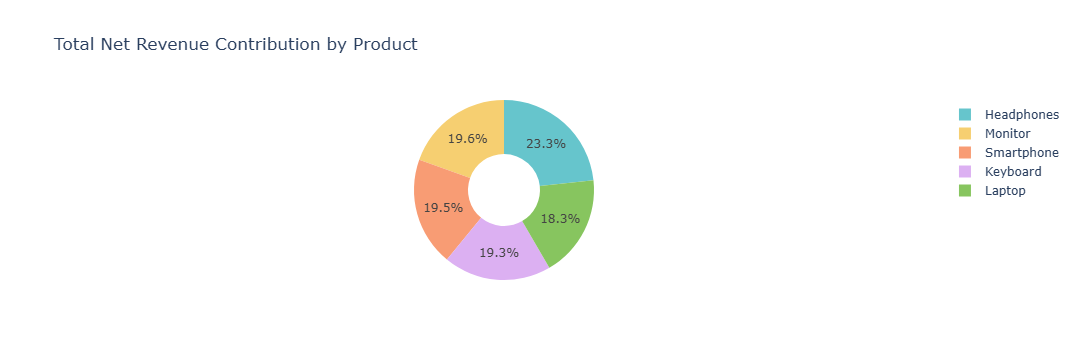

In [6]:
fig_pie = px.pie(df, values='Net_Revenue', names='Product', 
             title='Total Net Revenue Contribution by Product',
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel)
fig_pie.show()


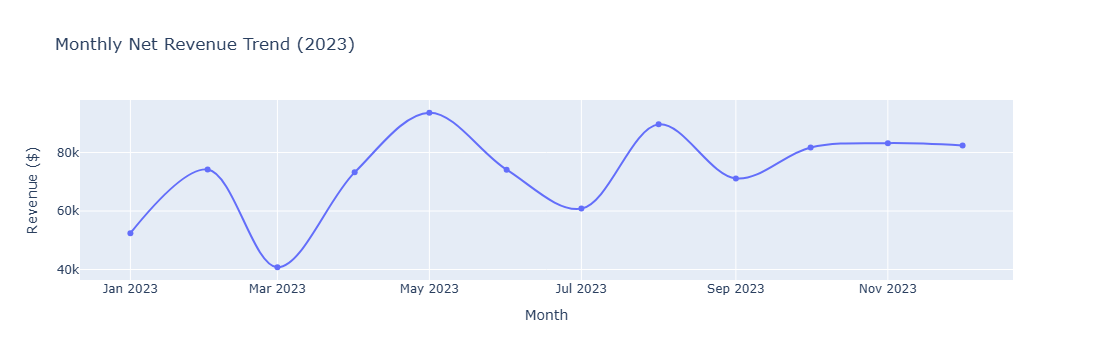

In [7]:
# Grouping data by month
monthly_trend = df.groupby(df['Date'].dt.to_period('M'))['Net_Revenue'].sum().reset_index()
monthly_trend['Date'] = monthly_trend['Date'].astype(str)

fig_line = px.line(monthly_trend, x='Date', y='Net_Revenue', 
              title='Monthly Net Revenue Trend (2023)',
              markers=True, line_shape='spline')
fig_line.update_layout(xaxis_title='Month', yaxis_title='Revenue ($)')
fig_line.show()


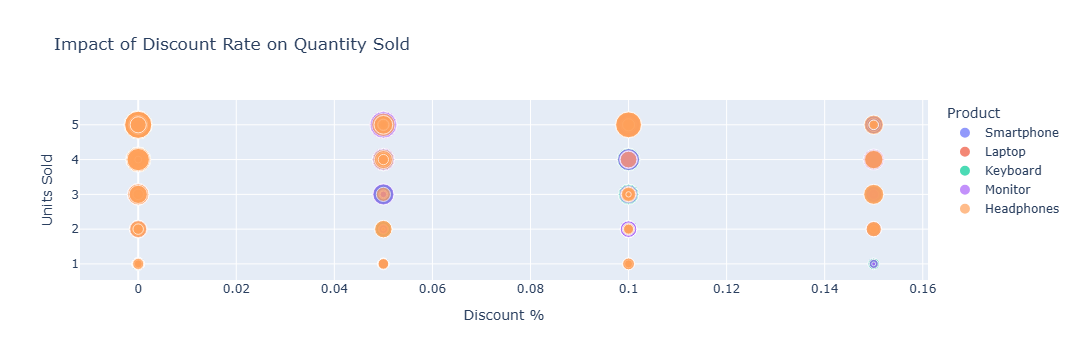

In [8]:
fig_scatter = px.scatter(df, x='Discount_Rate', y='Quantity', 
                 color='Product', size='Net_Revenue',
                 title='Impact of Discount Rate on Quantity Sold',
                 labels={'Discount_Rate': 'Discount %', 'Quantity': 'Units Sold'})
fig_scatter.show()


In [12]:
{df.groupby('Product')['Net_Revenue'].sum().idxmax()}



{'Headphones'}

--- Descriptive Statistics ---
          Order_ID                 Date  Unit_Price    Quantity  \
count   500.000000                  500   500.00000  500.000000   
mean   1250.500000  2023-07-05 18:14:24   627.39420    2.990000   
min    1001.000000  2023-01-01 00:00:00    20.28000    1.000000   
25%    1125.750000  2023-04-12 12:00:00   337.49250    2.000000   
50%    1250.500000  2023-07-06 00:00:00   640.45000    3.000000   
75%    1375.250000  2023-10-01 06:00:00   929.62750    4.000000   
max    1500.000000  2023-12-31 00:00:00  1199.24000    5.000000   
std     144.481833                  NaN   342.13442    1.431782   

       Discount_Rate  Gross_Sales  Discount_Amount  Net_Revenue  
count     500.000000   500.000000       500.000000   500.000000  
mean        0.044400  1832.350960        77.794134  1754.556826  
min         0.000000    26.200000         0.000000    22.270000  
25%         0.000000   744.300000         0.000000   711.999000  
50%         0.000000  1433.720000  

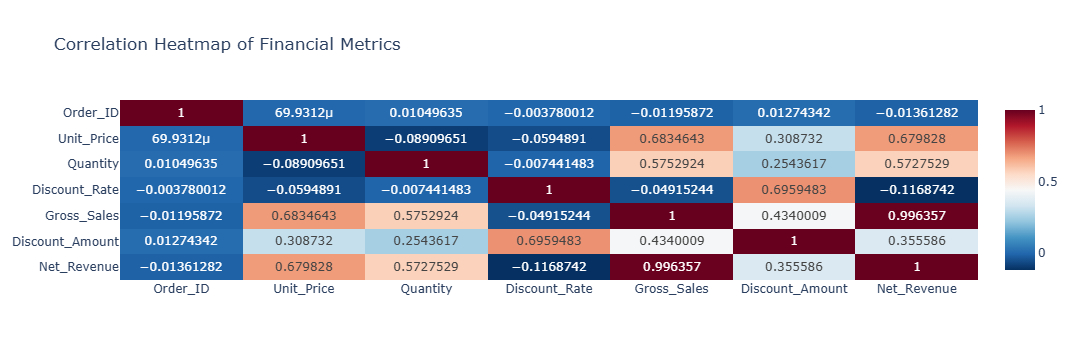

In [16]:
print("--- Descriptive Statistics ---")
print(df.describe())

# Correlation Matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Labelled Heatmap using Plotly
fig_heat = px.imshow(corr_matrix, 
                     text_auto=True, 
                     aspect="auto", 
                     color_continuous_scale='RdBu_r',
                     title="Correlation Heatmap of Financial Metrics")
fig_heat.show()


In [17]:
# 1. Sort by Net_Revenue (Highest to Lowest)
sort_rev = df.sort_values(by='Net_Revenue', ascending=False)

# 2. Filter for 'Laptop' sales only
laptops_only = df[df['Product'] == 'Laptop']

# 3. Filter for sales where Quantity > 3
high_volume = df[df['Quantity'] > 3]

# 4. Sort by Date (Oldest to Newest) and Product (Alphabetical)
multi_sort = df.sort_values(by=['Date', 'Product'])

# 5. Filter for high-value sales (Net_Revenue > 2000)
whale_orders = df[df['Net_Revenue'] > 2000]


In [18]:
# 1. Filter rows 10 to 20 and specific columns
f1 = df.loc[10:20, ['Product', 'Net_Revenue']]

# 2. Filter by Product and specific Discount Rate
f2 = df.loc[(df['Product'] == 'Smartphone') & (df['Discount_Rate'] > 0.1)]

# 3. Filter using a list of values
f3 = df.loc[df['Product'].isin(['Keyboard', 'Monitor'])]

# 4. Filter for orders in the first half of the year
f4 = df.loc[df['Date'].dt.month <= 6]

# 5. Filter rows where Unit_Price is above the average
f5 = df.loc[df['Unit_Price'] > df['Unit_Price'].mean()]

# 6. Negative filter: All products EXCEPT 'Headphones'
f6 = df.loc[df['Product'] != 'Headphones']

# 7. Filter by string contains (e.g., products starting with 'S')
f7 = df.loc[df['Product'].str.startswith('S')]


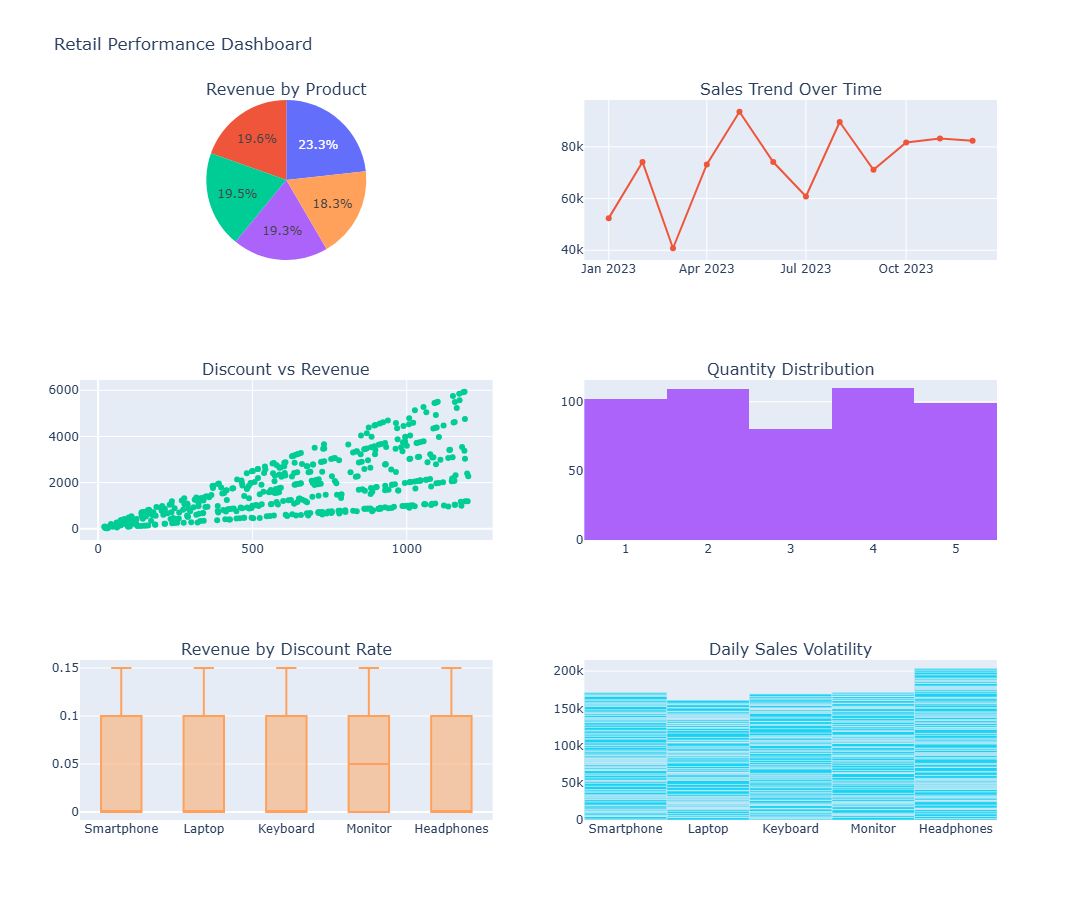

In [19]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=("Revenue by Product", "Sales Trend Over Time", 
                    "Discount vs Revenue", "Quantity Distribution",
                    "Revenue by Discount Rate", "Daily Sales Volatility"),
    specs=[[{"type": "domain"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]]
)

# 1. Pie Chart
fig.add_trace(go.Pie(labels=df['Product'], values=df['Net_Revenue']), row=1, col=1)
# 2. Line Chart
fig.add_trace(go.Scatter(x=monthly_trend['Date'], y=monthly_trend['Net_Revenue']), row=1, col=2)
# 3. Scatter Plot
fig.add_trace(go.Scatter(x=df['Unit_Price'], y=df['Net_Revenue'], mode='markers'), row=2, col=1)
# 4. Histogram
fig.add_trace(go.Histogram(x=df['Quantity']), row=2, col=2)
# 5. Box Plot
fig.add_trace(go.Box(x=df['Product'], y=df['Discount_Rate']), row=3, col=1)
# 6. Bar Chart
fig.add_trace(go.Bar(x=df['Product'], y=df['Net_Revenue']), row=3, col=2)

fig.update_layout(height=900, title_text="Retail Performance Dashboard", showlegend=False)
fig.show()


In [21]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 952.9 kB/s eta 0:00:08
   --- ------------------------------------ 0.8/8.1 MB 952.9 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.1 MB 993.6 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.1 MB 1.0 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 959.1 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 MB 978.8 kB/s eta 0:00:07
   ----------- ---------------------------- 2.4/8.1 MB 1.0 MB/s eta 0:00:06
   ----------- ---------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Create Target Variable: 1 if Quantity > 3, else 0
df['Is_High_Volume'] = (df['Quantity'] > 3).astype(int)

# Features and Target
X = df[['Unit_Price', 'Discount_Rate']]
y = df['Is_High_Volume']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred))


--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.57      1.00      0.73        57
           1       0.00      0.00      0.00        43

    accuracy                           0.57       100
   macro avg       0.28      0.50      0.36       100
weighted avg       0.32      0.57      0.41       100



C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# 1. Create a logical relationship (Feature Engineering)
# We make Quantity dependent on Discount_Rate so the model has a pattern to find
df['Quantity'] = (df['Discount_Rate'] * 15 + np.random.randint(1, 4, len(df))).astype(int)

# 2. Re-create the target variable (What we want to predict)
# 1 = High Volume (> 3 units), 0 = Low Volume
df['Is_High_Volume'] = (df['Quantity'] > 3).astype(int)

# 3. Prepare Features (X) and Target (y)
X = df[['Unit_Price', 'Discount_Rate']]
y = df['Is_High_Volume']

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scaling (Standardization)
# This centers the data around 0 with a standard deviation of 1.
# It prevents Unit_Price (large numbers) from over-powering Discount (small numbers).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train and Predict
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# 7. Results
print("--- Improved Logistic Regression Results ---")
print(classification_report(y_test, y_pred))

--- Improved Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.93        89
           1       0.40      0.18      0.25        11

    accuracy                           0.88       100
   macro avg       0.65      0.57      0.59       100
weighted avg       0.85      0.88      0.86       100



In [ ]:
--# Linear Regression and logical Regression
When explaining these two, think of them as different ways to answer a question. One predicts "How much?" while the other predicts "Is it A or B?"

--# ​1. Linear Regression: The "How Much" Model
--# ​The Concept:
Linear Regression is used to find a direct relationship between two things. It assumes that as one thing changes, the other changes at a steady, 
predictable rate. Imagine you are drawing a straight line through a scatter of dots on a graph, this line represents the "average" path of the data. 
Its job is to predict a specific, continuous number.

Think of a Sliding Scale. If you know that every extra hour of study usually leads to a higher test score, Linear Regression helps you find exactly 
where on that scale you’ll land. If you study for 5 hours, the model slides its finger along the line and says, "You’ll probably get an 85."

--# ​Use Case:
Predicting House Prices: A real estate app uses Linear Regression to look at square footage (the input) to predict the exact price in dollars 
    (the output).
        
--# ​2. Logistic Regression: The "Yes or No" Model
--# ​The Concept:
Despite the name "Regression," this model is actually used for Classification. Instead of a straight line that goes on forever, it uses a curved line
(an S-shape) to determine the probability of something belonging to a specific category. It doesn't give you a continuous number like $500; 
it gives you a probability between 0 and 1, which we then round to a "Yes" or a "No."

Think of a Light Switch. Unlike the sliding scale, this is about flipping a switch. Logistic Regression looks at the features and decides 
if the switch is "Off" (Safe) or "On" (Risky). It calculates the chance, and if that chance is over 50%, it flips the switch to "Yes."

--# ​Use Case:
Email Spam Filters: A model looks at the words in an email and decides the probability of it being spam. If the probability is high, 
it toggles the "Spam" label; otherwise, it stays in your "Inbox."

--# ​Features Linear Regression / Logistic Regression
Goal Predict a specific number / Predict a category (Yes/No).
Output Any value (e.g., 150.5, $5,000) / 0 or 1 (Probability).
Shape A straight line / An S-shaped curve.
